# CNN model

## note: basis of this CNN comes from this paper I found that also did a 3D CNN for MRI data
## Claude was used to interpret dimensional differences between their MRI data and ours so that CNN channel dimensions are correct

In [1]:
import numpy as np
import os
import pandas as pd
import nibabel as nib
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import f1_score
import torch.optim as optim

In [2]:
# mount colab and my personal drive (locaiton of OASIS data,
# both compressed and raw files written to it below)
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# variable for data connection!! use at top of files
DRIVE_ROOT  = "/content/drive/MyDrive/OASIS"
MRI_DIR = os.path.join(DRIVE_ROOT, "raw") # extracted imaging files in Drive
CSV_PATH = os.path.join(DRIVE_ROOT, "oasis_longitudinal.csv") # feature csv used for labeling


## Create labeled Dataset

In [4]:
# create label lookup df
df = pd.read_csv(CSV_PATH)
mri_cdr_labels = df[['MRI ID','CDR']]
# mri_cdr_labels.head()

In [5]:
# using to compress images for faster training / match paper's model dimensions
from scipy.ndimage import zoom

In [6]:
CDR_IDX = {0.0: 0, 0.5: 1, 1.0: 2}

# custom dataset including labels
class CustomMRIDataset(Dataset):

  def __init__(self, mri_dir, mri_cdr_labels):
    self.mri_dir = mri_dir
    # drop if empty of CDR >1 (only want three classes 0,.5,1)
    self.labels = mri_cdr_labels.dropna(subset=['CDR']).loc[mri_cdr_labels['CDR'] <= 1].reset_index(drop=True)

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    mri_id = self.labels.iloc[idx]['MRI ID']
    cdr = self.labels.iloc[idx]['CDR']

    # bc multiple runs of scanning per visit, average for that visit
    subject_dir = os.path.join(self.mri_dir, mri_id)
    scan_list = []
    for root, dirs, files in os.walk(subject_dir): # path needed for .img file
      for f in files:
        if f.endswith('.img'):
          # need .squeeze bc nib adds ending dim
          scan_list.append(nib.load(os.path.join(root, f)).get_fdata().squeeze())
    vol = np.mean(scan_list, axis=0)


    ######################
    # trying to improve efficiency in training by first resizing here
    vol = np.mean(scan_list, axis=0)

    # resize to (112, 112, 94) before tensorizing
    factors = [112/vol.shape[0], 112/vol.shape[1], 94/vol.shape[2]]
    vol = zoom(vol, factors, order=3)
    ####################

    # convert averaged scan to tensor
    vol = (vol - vol.mean()) / vol.std() # normalize MRI intensity vals

    # unsqueeze adds cnn needed extra dim! (need float type bc errors)
    tensor = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)

    # convert labels to tensor, need ints for pytorch
    label = torch.tensor(CDR_IDX[round(float(cdr), 1)], dtype=torch.long)

    return tensor, label

In [7]:
# utilize above class and pass to DataLoader from pytorch
# use 4 batch size bc availability of A100 GPU on colab
# use increased num_workers bc bottleneck of image processing
dataset = CustomMRIDataset(MRI_DIR, mri_cdr_labels)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2)

# skipping transforms bc data is consistent from scans (was pre-processed)
# and also we do in-line standardization above for intensity vals

In [8]:
# check datset shape -- need (1, 256, 256, 128) = (1, height, width, # slices)
volume, label = dataset[0]
print(volume.shape, label)

torch.Size([1, 112, 112, 94]) tensor(0)


## Build the NN

Mzoughi et al. model updated for our (B, 1, 256, 256, 128) input:


convolutional layers -- kernels w stride 1&2, batch norm, ReLU, max pooling
  
  Input - (B,   1, 256, 256, 128)
  
  Conv1 stride2 -> (B,  32, 128, 128,  64) - 32 kernels, stride 2
  
  Conv2 + pool2  -> (B,  64,  64,  64,  32) - 64 kernels, stride 1, max pooling
  
  Conv3 stride2 + pool3 -> (B, 128,  16,  16,   8) - 128 kernels, stride 2, max pooling
  
  Conv4 + pool4  -> (B, 256,   8,   8,   4) - 256 kernels, stride 1, max pooling
  
  Conv5 stride2  (B, 256,   4,   4,   2) - 256 kernels, stride 2


collapsing dimensions from (B, 256, 4, 4, 2) to (B, 256)
  AdaptiveAvgPool(B, 256,   1,   1,   1) --> (B, 256)


fully connected layers finally!
  FC-1/2/s

In [9]:
# class to combine: 3D convolution, batch normalization, and ReLU layers
class ConvCombined(nn.Module):
    def __init__(self, in_channel, out_channel, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channel, out_channel,
                      # using 3 x 3 x 3 kernels in convolution filter sliding
                      kernel_size=3, stride=stride, padding=1, bias=False),
            # batch norm rescales output activation signals
            # (paper used to make DL faster/stable)
            nn.BatchNorm3d(out_channel),
            nn.ReLU(inplace=True) # standard ReLU layer: max(0,x)
        )
    def forward(self, x):
        return self.block(x)

# actual 3D CNN model: layers as described above
class CNNModelFor3DMRI(nn.Module):
    """
      Input: (B, 1, 256, 256, 128) - see DataLoader above
      FC1: (B, 256) — features extracted for HMM
      Output: (B, 3) — CDR class logits
    """
    def __init__(self, n_classes=3):
        super().__init__()
        self.conv1 = ConvCombined(1, 32, stride=2)
        self.conv2 = ConvCombined(32, 64, stride=1)
        self.pool2 = nn.MaxPool3d(2, 2)
        self.conv3 = ConvCombined(64, 128, stride=2)
        self.pool3 = nn.MaxPool3d(2, 2)
        self.conv4 = ConvCombined(128, 256, stride=1)
        self.pool4 = nn.MaxPool3d(2, 2)
        self.conv5 = ConvCombined(256, 256, stride=2)

        # AdaptiveAvgPool collapses remaining dimensions (4,4,2) -> (1,1,1)
        # because we no longer care abt spatial location
        self.gap = nn.AdaptiveAvgPool3d(1)

        # Fully Connected layers (FC) - final feedforward layers
        # = every neuron connects to every activation from (B, 256) above
        # (randomly drop 50% of values in training to prevent overfitting)
        self.fc1 = nn.Sequential(nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.5))
        self.fc2 = nn.Sequential(nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.5))
        self.fc3 = nn.Linear(256, n_classes) # used for logits classification

    def _encode(self, x):
        x = self.conv1(x)
        x = self.pool2(self.conv2(x))
        x = self.pool3(self.conv3(x))
        x = self.pool4(self.conv4(x))
        x = self.conv5(x)
        return self.gap(x).flatten(1)

    def forward(self, x):
        x = self._encode(x)
        x = self.fc1(x)
        x = self.fc2(x)
        return self.fc3(x)

    def extract_features(self, x):
        #256-d embedding from FC-1, will use as observations for HMM
        return self.fc1(self._encode(x)) # (B, 256)



In [23]:
# yay we have a model!
model = CNNModelFor3DMRI()
model.to("cuda")

CNNModelFor3DMRI(
  (conv1): ConvCombined(
    (block): Sequential(
      (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv2): ConvCombined(
    (block): Sequential(
      (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): ConvCombined(
    (block): Sequential(
      (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (pool3): MaxPool3d(kernel_size=2, stride=2, padding=0, d

## Train model

In [33]:
import re

# load previous epoch data
save_dir = "/content/drive/MyDrive/OASIS"
saved = [f for f in os.listdir(save_dir) if f.startswith("model_epoch") and f.endswith(".pth")]
epochs_found = sorted([int(re.search(r"epoch(\d+)", f).group(1)) for f in saved])
latest_epoch = epochs_found[-1]

print(f"Found saved epochs: {epochs_found}")
print(f"Loading epoch {latest_epoch}, resuming from epoch {latest_epoch + 1}")

model = CNNModelFor3DMRI()
model.load_state_dict(torch.load(f"{save_dir}/model_epoch{latest_epoch}.pth"))
model.to("cuda")

Found saved epochs: [1, 2, 3]
Loading epoch 3, resuming from epoch 4


CNNModelFor3DMRI(
  (conv1): ConvCombined(
    (block): Sequential(
      (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv2): ConvCombined(
    (block): Sequential(
      (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): ConvCombined(
    (block): Sequential(
      (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (pool3): MaxPool3d(kernel_size=2, stride=2, padding=0, d

In [34]:
# training function
def train(model, loader, n_epochs=5, lr=1e-3, weights=None):
    model.to("cuda")
    # using optimizer from paper and typical cross entropy loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=weights) # need weights bc class imbalance
    # basically, want to weight the incorrect classification of smaller classes

    # for given number of epochs
    for epoch in range(n_epochs):
        model.train()
        total_loss, correct, n = 0, 0, 0 # initialize to zeros
        all_preds, all_labels_list = [], []

        for vols, labels in tqdm(loader, desc=f"Epoch {latest_epoch+epoch+1}"):
            vols, labels = vols.to("cuda"), labels.to("cuda") # specify GPU
            optimizer.zero_grad() # wipe gradients
            logits = model(vols) # forward pass
            loss = criterion(logits, labels) # compute loss
            loss.backward() # compute new gradients based on loss
            optimizer.step() # update model weights using gradients

            n += len(labels)
            # add avg loss for batch to total
            total_loss += loss.item() * len(labels)
            # update accuracy
            correct += (logits.argmax(1) == labels).sum().item()

            # update pieces for f1 score calculation
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels_list.extend(labels.cpu().numpy())

        f1 = f1_score(all_labels_list, all_preds, average='weighted')
        print(f"Epoch {latest_epoch+epoch+1:02d} | loss {total_loss/n:.4f} | acc {correct/n:.4f} | f1 {f1:.4f}")
        # reduce re-running training, save current training
        torch.save(model.state_dict(), f"/content/drive/MyDrive/OASIS/model_epoch{latest_epoch+epoch+1}.pth")

    return model

In [35]:
# utilizing weights from class distributions to avoid first training round problems
counts = dataset.labels['CDR'].value_counts()
total  = len(dataset.labels)

w0  = total / counts[0.0] # CDR 0
w05 = total / counts[0.5] # CDR 0.5
w1  = total / counts[1.0] # CDR 1

# big class imbalance
w = torch.tensor([w0, w05, w1], dtype=torch.float32).to("cuda")
print(w)

tensor([1.7961, 3.0081, 9.0244], device='cuda:0')


In [36]:
train(model, dataloader, n_epochs=3, weights=w)

Epoch 4: 100%|██████████| 93/93 [11:20<00:00,  7.32s/it]


Epoch 04 | loss 1.0313 | acc 0.5324 | f1 0.5100


Epoch 5: 100%|██████████| 93/93 [11:47<00:00,  7.61s/it]


Epoch 05 | loss 1.0461 | acc 0.5027 | f1 0.4777


Epoch 6: 100%|██████████| 93/93 [11:36<00:00,  7.49s/it]

Epoch 06 | loss 1.0270 | acc 0.4757 | f1 0.4869


CNNModelFor3DMRI(
  (conv1): ConvCombined(
    (block): Sequential(
      (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv2): ConvCombined(
    (block): Sequential(
      (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): ConvCombined(
    (block): Sequential(
      (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (pool3): MaxPool3d(kernel_size=2, stride=2, padding=0, d

## Evaluation and Feature Extraction



In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pickle

In [41]:
## load epoch 4 because of best numbers (f1 score > .5)
model = CNNModelFor3DMRI()
model.load_state_dict(torch.load("/content/drive/MyDrive/OASIS/model_epoch4.pth", weights_only=True))
model.to("cuda")
print("Loaded epoch 4")

Loaded epoch 4


In [42]:
# model evaluation -- same time as running 1 epoch in training
model.eval()
subject_features = {}
all_preds, all_true, all_embeddings, all_embedding_labels = [], [], [], []

eval_loader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

with torch.no_grad():
    batch_start_idx = 0
    for vols, labels in tqdm(eval_loader):
        vols = vols.to("cuda")

        # single forward pass to extract both features and logits used in eval
        enc = model._encode(vols) # (B, 256)
        feats = model.fc1(enc).cpu().numpy() # (B, 256) - HMM features
        logits = model.fc3(model.fc2(model.fc1(enc))).cpu().numpy() # (B, 3)

        # for confusion matrix and PCA
        all_preds.extend(logits.argmax(1).tolist())
        all_true.extend(labels.numpy().tolist())
        all_embeddings.extend(feats)
        all_embedding_labels.extend(labels.numpy().tolist())

        # group features by subject for HMM
        for i in range(len(labels)):
            idx = batch_start_idx + i
            mri_id = dataset.labels.iloc[idx]['MRI ID']
            subject_id = mri_id.rsplit("_MR", 1)[0]
            subject_features.setdefault(subject_id, []).append(feats[i])

        batch_start_idx += len(labels)

subject_features = {sid: np.stack(visits) for sid, visits in subject_features.items()}

100%|██████████| 93/93 [17:06<00:00, 11.03s/it]


In [45]:
# save features as pickle
with open("/content/drive/MyDrive/OASIS/cnn_features.pkl", "wb") as f:
    pickle.dump(subject_features, f)

print(f"Saved {len(subject_features)} subjects")

Saved 150 subjects


In [49]:
# test opening pickle file for HMM
with open("/content/drive/MyDrive/OASIS/cnn_features.pkl", "rb") as f:
    features = pickle.load(f)

# print first 5 available subjects
print(f"Subjects in file: {list(features.keys())[:5]}...")

# test subject 1 and visit 0
subject_id = "OAS2_0001"
visit_idx  = 0
print(f"\n{subject_id} — {features[subject_id].shape[0]} visits total")
print(f"Visit {visit_idx} feature vector shape: {features[subject_id][visit_idx].shape}") # should be (256,)
print(f"Visit {visit_idx} first 5 values: {features[subject_id][visit_idx][:5]}")

Subjects in file: ['OAS2_0001', 'OAS2_0002', 'OAS2_0004', 'OAS2_0005', 'OAS2_0007']...

OAS2_0005 — 3 visits total
Visit 1 feature vector shape: (256,)
Visit 1 first 5 values: [0. 0. 0. 0. 0.]


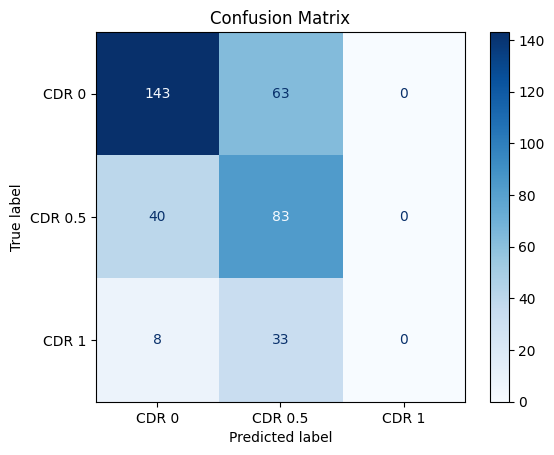

In [43]:
# confusion matrix
cm = confusion_matrix(all_true, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["CDR 0", "CDR 0.5", "CDR 1"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

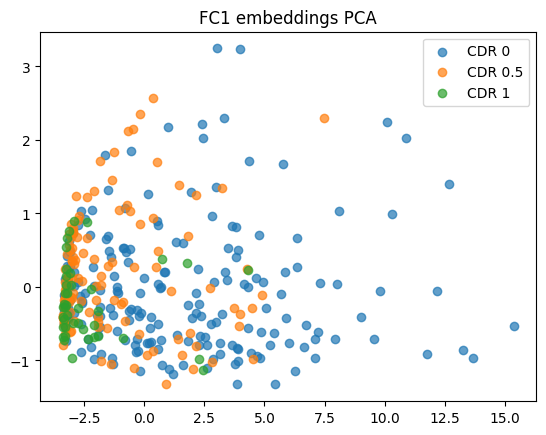

In [44]:
# PCA
reduced = PCA(n_components=2).fit_transform(np.stack(all_embeddings))
for idx, label in enumerate(["CDR 0", "CDR 0.5", "CDR 1"]):
    mask = np.array(all_embedding_labels) == idx
    plt.scatter(reduced[mask, 0], reduced[mask, 1], label=label, alpha=0.7)
plt.legend()
plt.title("FC1 embeddings PCA")
plt.show()

## Overfitting?

In [20]:
from torch.utils.data import random_split

# split dataset
train_size    = int(0.8 * len(dataset))
val_size      = len(dataset) - train_size
train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
print(f"Val set: {val_size} samples")

# run validation only on current model
model.eval()
val_preds, val_true = [], []

with torch.no_grad():
    for vols, labels in tqdm(val_loader, desc="Validating"):
        vols, labels = vols.to("cuda"), labels.to("cuda")
        logits = model(vols)
        val_preds.extend(logits.argmax(1).cpu().numpy())
        val_true.extend(labels.cpu().numpy())

val_f1 = f1_score(val_true, val_preds, average='weighted')
val_acc = sum(p == t for p, t in zip(val_preds, val_true)) / len(val_true)
print(f"Val acc {val_acc:.4f} | val f1 {val_f1:.4f}")

Val set: 74 samples


Validating: 100%|██████████| 19/19 [01:50<00:00,  5.84s/it]

Val acc 0.5676 | val f1 0.4271
